BT6270: Computational Neuroscience
Assignment 2
By Kalaiyarasu | bs22b019

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Fitz-Hugh Nagumo Model

The Fitz-Hugh Nagumo model is defined by 2 first-order differential equations:<br><br>
1. $\frac{dv}{dt} = f(v) - w + I $, where $f(v) = v(a-v)(v-1)$ <br><br>
2. $\frac{dw}{dt} = bv - rw$ <br>

Here, $v$ is analogous to the membrane voltage, and $w$ represents all
the three gating variables from the Hodgkin Huxley model (h, m, n).

Thus, we get the nullclines (the set of points where the derivative of v and w with respect to time i.e., their rate of change is zero) as such: <br>
$F(v,w) = f(v) - w + I = 0$,  and  $g(v,w) = bv - rw = 0$

In [ ]:
class FHNModel():
    def __init__(self, v0 = None, w0 = None, a = 0.5, b = 0.1, r = 0.1, dt = 0.1, iter = 1000):
        #Initializing the constants first, according to the question:
        self.a = a
        self.b = b
        self.r = r
        self.v = 0 if v0 == None else v0
        self.w = 0 if w0 == None else w0

        self.dt = dt #Time step variable
        self.iter = iter #Number of iterations
        #Note that total time = iter * dt

        #The following variables keep track of the two system variables as they are updated over the iterations, so that they can be used for plotting later.
        self.v_hist = []
        self.w_hist = []

    def f(self, v):
        return v * (self.a - v) * (v - 1)

    def dv(self, v, w, I):
        return self.f(v) - w + I

    def dw(self, v, w):
        return self.b * v - self.r * w

    def forward_integration(self, I_ext):
        #forward euler integration method, to calculate v and w values over time:
        dt = self.dt
        iter = self.iter

        for i in range(iter):
            dv = self.dv(self.v, self.w, I_ext)
            dw = self.dw(self.v, self.w)

            self.v += dv * dt
            self.w += dw * dt

            self.v_hist.append(self.v)
            self.w_hist.append(self.w)

        return self.v_hist, self.w_hist

    def get_v_nc(self, v, I_ext): #v nullcline
        return self.f(v) + I_ext

    def get_w_nc(self, v): #w nullcline
        return self.b * v/self.r

#Simulating the model
##Plotting functions
First, I'll define a general plotter function for the phase plots of v and w and their nullclines:

In [ ]:
def phase_plotter(I_ext, y_range, x_range, points = None, b = None, r = None):
    plt.figure()

    #This creates an evenly spaced grid of v and w values based on the given ranges.
    v = np.linspace(x_range[0], x_range[1], 100)
    w = np.linspace(x_range[0], x_range[1], 100)

    #Plotting the nullclines:
    FHN = FHNModel(b = b, r = r) if (b and r) else FHNModel()
    v_nc = FHN.get_v_nc(v, I_ext)
    w_nc = FHN.get_w_nc(v)

    plt.plot(v, v_nc, 'r')
    plt.plot(w, w_nc, 'b')
    plt.legend(['v-nullcline', 'w-nullcline'])
    plt.ylim(y_range[0], y_range[1])
    plt.title(f"Phase plot for I_ext = {I_ext}")
    plt.xlabel('v')
    plt.ylabel('w')

    #Plotting the phase plot's streamlines:
    v_grid, w_grid = np.meshgrid(v, w) #Gives a rectangular grid of x & y coordinates, such that the rates can be calculated at each coordinate of the phase plane as done below:

    v_rate = FHN.dv(v_grid, w_grid, I_ext)
    w_rate = FHN.dw(v_grid, w_grid)

    colors = ['y', 'g', 'c', 'm', 'k'] * 3 #To distinguish between streamlines from distinct starting points on the phase space
    if points:
        for i in range(len(points)):
            plt.streamplot(v_grid, w_grid, v_rate, w_rate, density=2, start_points = [points[i]], color = colors[i], integration_direction = "forward", arrowsize = 2) #This plots each streamline from a given start point on the phase space
    else:
        #If no specific starting points are given, we plot streamlines across the entire phase space
        plt.streamplot(v_grid, w_grid, v_rate, w_rate, color = 'silver')

    plt.grid()
    plt.show()

And another plotter function, to plot v and w with respect to time:

In [ ]:
def time_plotter(v0, w0, I_ext, title, y_range = None, b = None, r = None):
    #Here, v_hist and w_hist will be plotted on the y-axis; and t denotes the time duration to be plotted on the x-axis.
    t = list(np.linspace(0, 100, 1000)) #This creates an evenly-spaced array with a total of 1000 units, since that is the default number of iterations for our model.
    plt.figure()

    FHN = FHNModel(v0 = v0, w0 = w0, b = b, r = r) if (b and r) else FHNModel(v0 = v0, w0 = w0)
    v_hist, w_hist = FHN.forward_integration(I_ext)

    plt.plot(t, v_hist, color = 'red')
    plt.plot(t, w_hist, color = 'blue')

    if y_range: plt.ylim(y_range)

    plt.ylabel('v and w (voltage) values')
    plt.xlabel('Time (s)')
    plt.title(title)

    plt.legend(["v(t)", "w(t)"])
    plt.grid()
    plt.show()

##Case 1: I = 0 (Excitability)
###a). Phase plot for I = 0


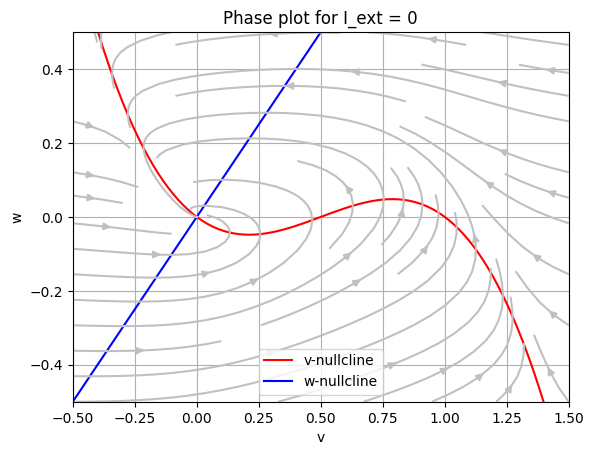

In [ ]:
phase_plotter(0, (-0.5, 0.5), (-0.5, 1.5))

### b). V and W v/s t
#### i. V(0) < a and W(0) = 0



#### ii. V(0) > a and W(0) = 0

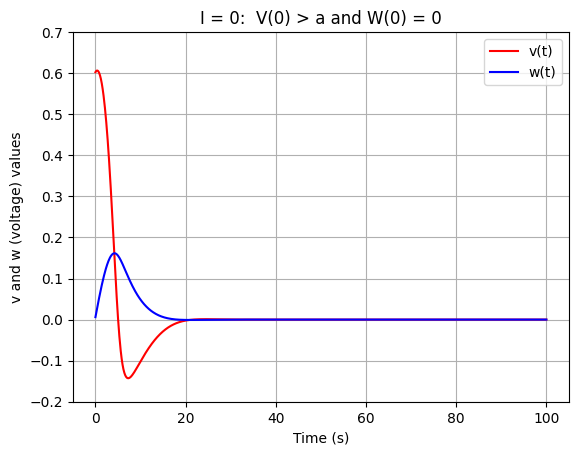

In [ ]:
time_plotter(0.6, 0, 0, title = "I = 0:  V(0) > a and W(0) = 0", y_range = (-0.2, 0.7))

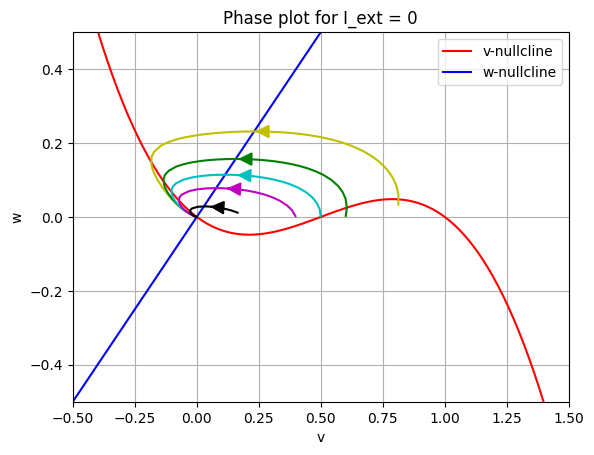

In [ ]:
phase_plotter(0, (-0.5, 0.5), (-0.5, 1.5), [[0.8, 0], [0.6, 0], [0.5, 0], [0.4, 0], [0.2, 0]])

## Case 2: I1 < I < I2 (Limit Cycles/Oscillations)
### a). Phase plot for I = 0.5

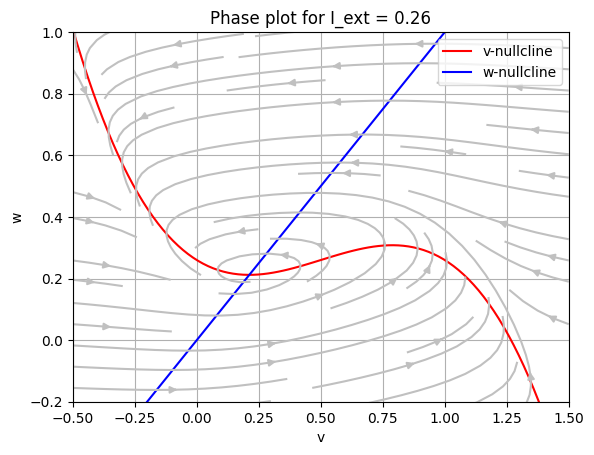

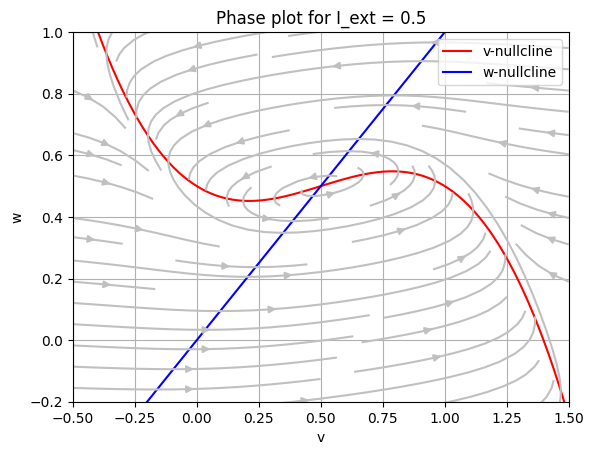

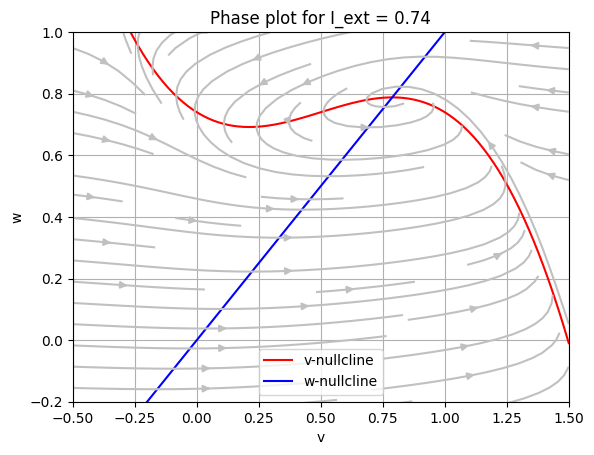

In [ ]:
for i in [0.26, 0.5, 0.74]:
    phase_plotter(i, (-0.2, 1), (-0.5, 1.5))

###b). Unstability of fixed point

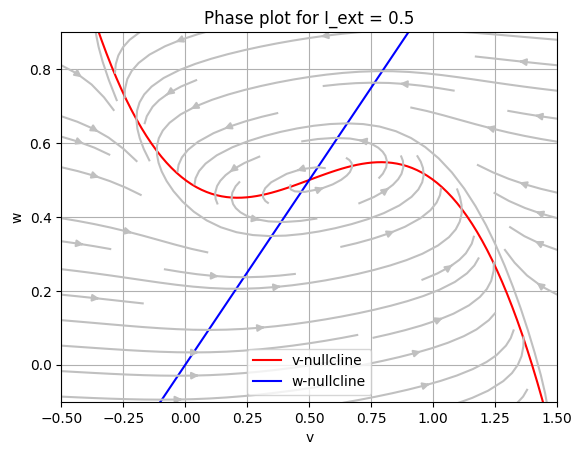

In [ ]:
phase_plotter(0.5, (-0.1, 0.9), (-0.5, 1.5))

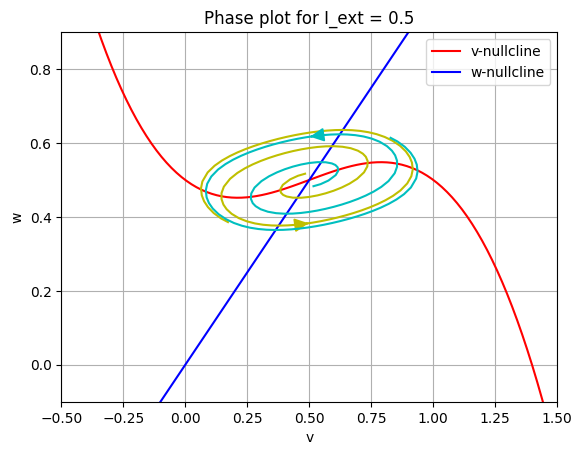

In [ ]:
phase_plotter(0.5, (-0.1, 0.9), (-0.5, 1.5), [[0.52, 0.52], [0.5, 0.5], [0.48, 0.48]])

### c). V and W v/s t

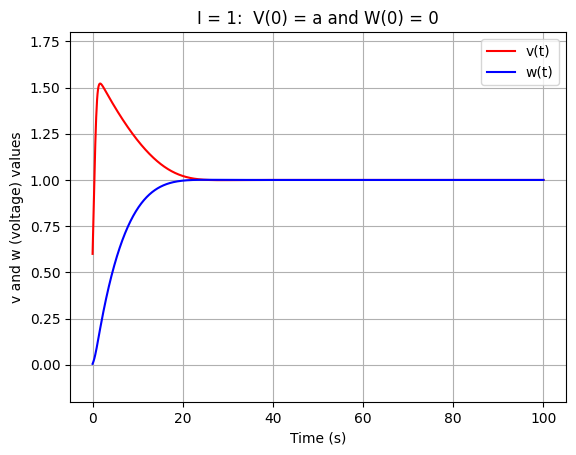

In [ ]:
time_plotter(0.5, 0, 1, title = "I = 1:  V(0) = a and W(0) = 0", y_range = (-0.2, 1.8))

##Case 4: Bistability

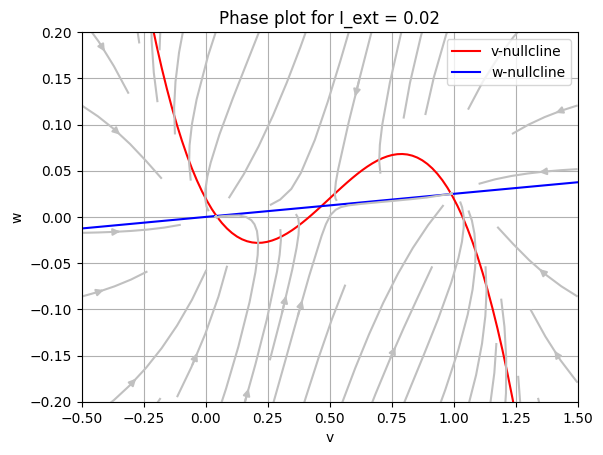

In [ ]:
phase_plotter(0.02, (-0.2, 0.2), (-0.5, 1.5), b = 0.02, r = 0.8)

###b). Stability/Unstability of 3 fixed points

Upon inspecting the above plot, we can see that the three fixed points lie between (0, 0) and (1, 0.3). Thus, we can create streamlines for starting points within this range to examine the stability around these fixed points:

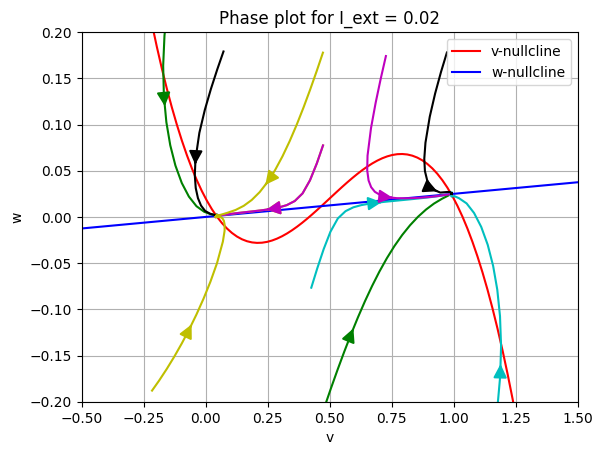

In [ ]:
phase_plotter(0.02, (-0.2, 0.2), (-0.5, 1.5), [[0.5, 0.1], [0, 0.4], [0.4, -0.1], [0.5, 0.1], [0.1, 0.2], [-0.25, -0.2], [0.25, -0.4], [1, -0.4], [0.75, 0.2], [1.0, 0.2], [0.5, 0.2]], b = 0.02, r = 0.8)

###c). V and W v/s t

The value chosen for v(0) matters here, leading the neuron to be in either an 'up' or 'down' state:


For v(0) > a, and w(0) = 0:

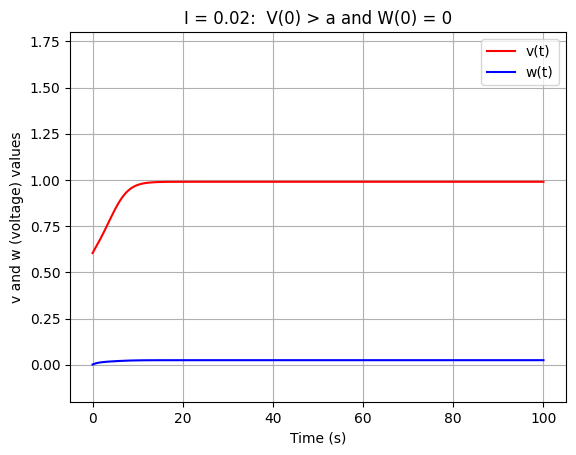

In [ ]:
time_plotter(0.6, 0, 0.02, title = "I = 0.02:  V(0) > a and W(0) = 0", y_range = (-0.2, 1.8), b = 0.02, r = 0.8)

For v(0) < a, and w(0) = 0:

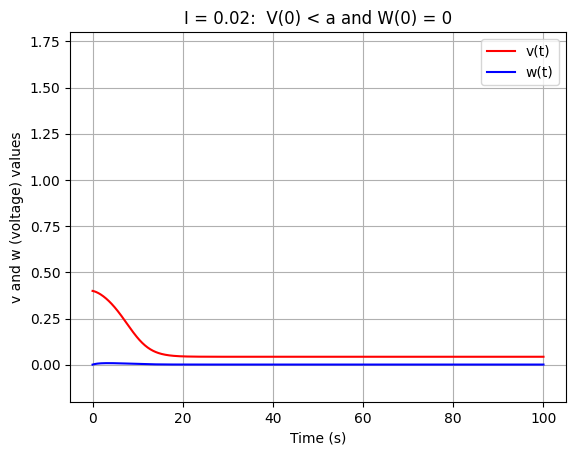

In [ ]:
time_plotter(0.4, 0, 0.02, title = "I = 0.02:  V(0) < a and W(0) = 0", y_range = (-0.2, 1.8), b = 0.02, r = 0.8)